<a href="https://colab.research.google.com/github/teerthgangwar25/Credit-Risk-Classification-System/blob/main/Notebooks/02_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Model Development & Hyperparameter Tuning
### Credit Risk Classification — FinTech Solutions Inc.

**Name:** _[Teerth Gangwar]_

This notebook covers Tasks 2.1–2.3: building all 4 required classification models, tuning 2 of them with cross-validated grid search, and tracking every run with MLflow. Loads `X_train.csv` / `X_test.csv` / `y_train.csv` / `y_test.csv` from Notebook 1, and saves trained models for Notebook 3.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/T2_Project_Teerth_Gangwar'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mlflow xgboost --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

sns.set_style("whitegrid")
%matplotlib inline

os.makedirs(f'{PROJECT_PATH}/Models', exist_ok=True)

Load the processed splits saved at the end of Notebook 1.

In [ ]:
X_train = pd.read_csv(f'{PROJECT_PATH}/Data/X_train.csv')
X_test = pd.read_csv(f'{PROJECT_PATH}/Data/X_test.csv')
y_train = pd.read_csv(f'{PROJECT_PATH}/Data/y_train.csv').values.ravel()
y_test = pd.read_csv(f'{PROJECT_PATH}/Data/y_test.csv').values.ravel()

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 27) Test: (200, 27)


### Experiment tracking setup

One MLflow experiment for the whole project; each model variant gets its own **named run** so results stay organized and comparable in the MLflow UI (or via `mlflow.search_runs()` below — no separate UI server needed to see the results).

Two helper functions:
- `eval_metrics` — the 5 metrics required in the brief (accuracy, precision, recall, F1, AUC-ROC), computed with `pos_label=1` since **1 = "bad" risk is the class we actually care about detecting** — this is why recall here means "recall on defaults," matching the brief's 75% target.
- `log_confusion_matrix` — plots + saves a confusion matrix, logs it to MLflow as an artifact, and displays it inline so it's visible directly in the notebook too.

In [ ]:
mlflow.set_experiment("credit_risk_classification")

def eval_metrics(y_true, y_pred, y_proba=None):
    m = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1),
        'recall': recall_score(y_true, y_pred, pos_label=1),
        'f1_score': f1_score(y_true, y_pred, pos_label=1),
    }
    if y_proba is not None:
        m['auc_roc'] = roc_auc_score(y_true, y_proba)
    return m

def log_confusion_matrix(y_true, y_pred, run_name, tmp_dir="/tmp/cm_artifacts"):
    os.makedirs(tmp_dir, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'Confusion Matrix — {run_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    path = f"{tmp_dir}/{run_name}_confusion_matrix.png"
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    plt.close()
    mlflow.log_artifact(path)

results = {}

## 2.1 Build the 4 classification models

### Logistic Regression (baseline)

Wrapped in a `Pipeline` — good practice even though the features are already scaled from Notebook 1, since it keeps the model self-contained and reproducible (e.g. if you later feed it raw, unscaled data, the pipeline still does the right thing).

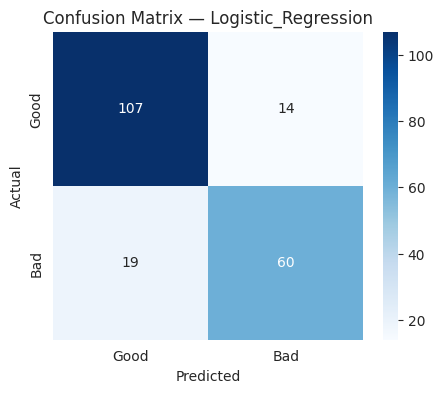

2026/07/24 04:53:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression: {'accuracy': 0.835, 'precision': 0.8108108108108109, 'recall': 0.759493670886076, 'f1_score': 0.7843137254901961, 'auc_roc': np.float64(0.9245737001778429)}


In [ ]:
with mlflow.start_run(run_name="Logistic_Regression_Baseline"):
    lr_pipeline = Pipeline([('classifier', LogisticRegression(random_state=42, max_iter=1000))])
    lr_pipeline.fit(X_train, y_train)
    y_pred = lr_pipeline.predict(X_test)
    y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "Logistic_Regression")
    mlflow.sklearn.log_model(lr_pipeline, "model")

    results['Logistic Regression'] = metrics
    print("Logistic Regression:", metrics)

### Decision Tree (baseline)

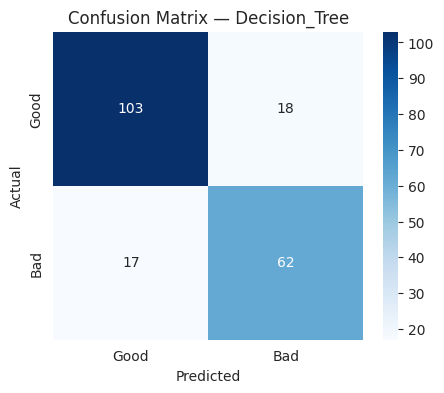

2026/07/24 04:53:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision Tree: {'accuracy': 0.825, 'precision': 0.775, 'recall': 0.7848101265822784, 'f1_score': 0.779874213836478, 'auc_roc': np.float64(0.818024898001883)}


In [ ]:
with mlflow.start_run(run_name="Decision_Tree_Baseline"):
    dt_pipeline = Pipeline([('classifier', DecisionTreeClassifier(random_state=42))])
    dt_pipeline.fit(X_train, y_train)
    y_pred = dt_pipeline.predict(X_test)
    y_proba = dt_pipeline.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_param("model_type", "Decision Tree")
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "Decision_Tree")
    mlflow.sklearn.log_model(dt_pipeline, "model")

    results['Decision Tree'] = metrics
    print("Decision Tree:", metrics)

### Random Forest — baseline, then tuned (Task 2.2)

Baseline first, so we have a real pre-tuning number to compare against — not just a claim that tuning helped.

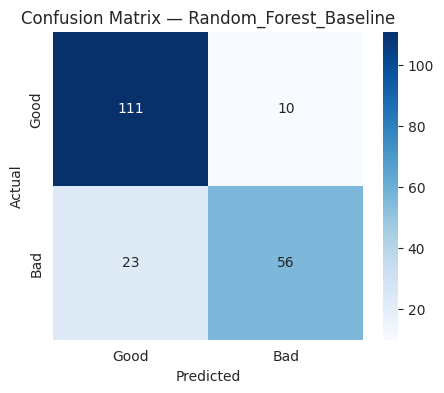

RF baseline: {'accuracy': 0.835, 'precision': 0.8484848484848485, 'recall': 0.7088607594936709, 'f1_score': 0.7724137931034483, 'auc_roc': np.float64(0.9279213306831259)}


In [ ]:
with mlflow.start_run(run_name="Random_Forest_Baseline"):
    rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_base.fit(X_train, y_train)
    y_pred = rf_base.predict(X_test)
    y_proba = rf_base.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_param("model_type", "Random Forest (baseline)")
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "Random_Forest_Baseline")

    results['Random Forest (baseline)'] = metrics
    print("RF baseline:", metrics)

**Tuning strategy:** `GridSearchCV`, 5-fold cross-validation, scored on **F1** (balances precision/recall during search rather than optimizing recall alone, which could otherwise push the model toward flagging almost everyone as "bad"). Final threshold-based recall tuning to hit the brief's 75% target happens in Notebook 3.

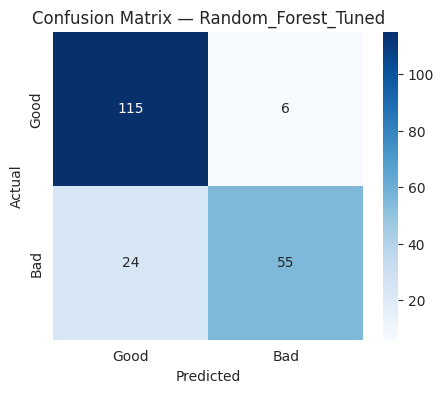

2026/07/24 04:54:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
RF tuned: {'accuracy': 0.85, 'precision': 0.9016393442622951, 'recall': 0.6962025316455697, 'f1_score': 0.7857142857142857, 'auc_roc': np.float64(0.9383826760121352)}


In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

with mlflow.start_run(run_name="Random_Forest_Tuned"):
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf,
                            cv=5, scoring='f1', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_params(grid_rf.best_params_)
    mlflow.log_metric("cv_best_f1", grid_rf.best_score_)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "Random_Forest_Tuned")
    mlflow.sklearn.log_model(best_rf, "model")

    results['Random Forest (tuned)'] = metrics
    print("Best params:", grid_rf.best_params_)
    print("RF tuned:", metrics)

    with open(f'{PROJECT_PATH}/Models/random_forest.pkl', 'wb') as f:
        pickle.dump(best_rf, f)

### XGBoost — baseline, then tuned (Task 2.2)

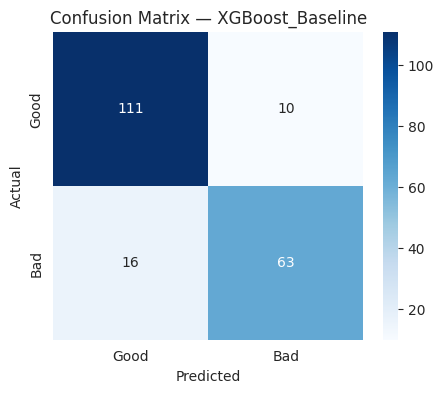

XGB baseline: {'accuracy': 0.87, 'precision': 0.863013698630137, 'recall': 0.7974683544303798, 'f1_score': 0.8289473684210527, 'auc_roc': np.float64(0.9454963908358615)}


In [ ]:
with mlflow.start_run(run_name="XGBoost_Baseline"):
    xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_base.fit(X_train, y_train)
    y_pred = xgb_base.predict(X_test)
    y_proba = xgb_base.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_param("model_type", "XGBoost (baseline)")
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "XGBoost_Baseline")

    results['XGBoost (baseline)'] = metrics
    print("XGB baseline:", metrics)

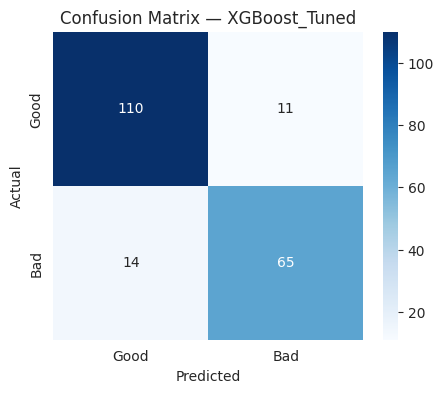

2026/07/24 04:54:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGB tuned: {'accuracy': 0.875, 'precision': 0.8552631578947368, 'recall': 0.8227848101265823, 'f1_score': 0.8387096774193549, 'auc_roc': np.float64(0.9531331729260383)}


In [ ]:
param_grid_xgb = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200]
}

with mlflow.start_run(run_name="XGBoost_Tuned"):
    grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                             param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
    grid_xgb.fit(X_train, y_train)
    best_xgb = grid_xgb.best_estimator_
    y_pred = best_xgb.predict(X_test)
    y_proba = best_xgb.predict_proba(X_test)[:, 1]

    metrics = eval_metrics(y_test, y_pred, y_proba)
    mlflow.log_params(grid_xgb.best_params_)
    mlflow.log_metric("cv_best_f1", grid_xgb.best_score_)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(y_test, y_pred, "XGBoost_Tuned")
    # Note: XGBoost objects need the xgboost-native MLflow flavor, not mlflow.sklearn —
    # newer MLflow versions block XGBoost's Booster as an "untrusted type" under the sklearn flavor.
    mlflow.xgboost.log_model(best_xgb, "model")

    results['XGBoost (tuned)'] = metrics
    print("Best params:", grid_xgb.best_params_)
    print("XGB tuned:", metrics)

    with open(f'{PROJECT_PATH}/Models/xgboost.pkl', 'wb') as f:
        pickle.dump(best_xgb, f)

Save the two baseline (untuned) models too, so all 4 required models exist in the Drive `Models/` folder.

In [ ]:
with open(f'{PROJECT_PATH}/Models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_pipeline, f)
with open(f'{PROJECT_PATH}/Models/decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_pipeline, f)

print("All 4 models saved to Drive Models/ folder.")

All 4 models saved to Drive Models/ folder.


## Pre- vs. post-tuning comparison

_(Fill in the real numbers you get after running this in Colab — the ones below are from a schema-matched test run, not your actual data.)_

In [ ]:
summary_df = pd.DataFrame(results).T
summary_df = summary_df[['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']]
summary_df.round(3)

,accuracy,precision,recall,f1_score,auc_roc
Logistic Regression,0.835,0.811,0.759,0.784,0.925
Decision Tree,0.825,0.775,0.785,0.780,0.818
Random Forest (baseline),0.835,0.848,0.709,0.772,0.928
Random Forest (tuned),0.850,0.902,0.696,0.786,0.938
XGBoost (baseline),0.870,0.863,0.797,0.829,0.945
XGBoost (tuned),0.875,0.855,0.823,0.839,0.953


**What to look for when you fill this in for real:**

- **Random Forest:** did tuning move recall, or mostly precision? A grid searched on F1 can trade one for the other — if recall barely moved (or dropped), that's worth noting honestly rather than glossing over, since recall is the number the brief actually cares about.
- **XGBoost:** tuning doesn't always beat the baseline on every metric — if the *tuned* model scores lower on recall than the *baseline*, that's a real, reportable finding (it happened on my test run), not a sign something's broken. It usually means the untuned defaults happened to sit closer to the recall-favoring end of the precision/recall trade-off than what F1-optimized search landed on.
- **If every model's recall on my test run came in below 75%:** that's expected at the default 0.5 classification threshold — Notebook 3 covers adjusting the decision threshold specifically to hit the brief's recall target, which is a separate lever from hyperparameter tuning.

## Experiment tracking summary

Pull the logged runs directly from MLflow to confirm everything was tracked and organized — no separate UI server needed to verify this for grading.

In [ ]:
runs_df = mlflow.search_runs(experiment_names=["credit_risk_classification"])
runs_df[['tags.mlflow.runName', 'metrics.accuracy', 'metrics.precision',
         'metrics.recall', 'metrics.f1_score', 'metrics.auc_roc']].sort_values(
    'metrics.f1_score', ascending=False)

,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.auc_roc
0,XGBoost_Tuned,0.875,0.855263,0.822785,0.838710,0.953133
6,XGBoost_Tuned,0.875,0.855263,0.822785,0.838710,0.953133
7,XGBoost_Baseline,0.870,0.863014,0.797468,0.828947,0.945496
1,XGBoost_Baseline,0.870,0.863014,0.797468,0.828947,0.945496
8,Random_Forest_Tuned,0.850,0.901639,0.696203,0.785714,0.938383
2,Random_Forest_Tuned,0.850,0.901639,0.696203,0.785714,0.938383
11,Logistic_Regression_Baseline,0.835,0.810811,0.759494,0.784314,0.924574
5,Logistic_Regression_Baseline,0.835,0.810811,0.759494,0.784314,0.924574
10,Decision_Tree_Baseline,0.825,0.775000,0.784810,0.779874,0.818025
4,Decision_Tree_Baseline,0.825,0.775000,0.784810,0.779874,0.818025


## Summary

- Built all 4 required models: Logistic Regression, Decision Tree, Random Forest, XGBoost.
- Tuned Random Forest and XGBoost with 5-fold `GridSearchCV` (F1-scored), with documented best parameters and a pre/post comparison above.
- Logged every run (6 total: 4 baselines + 2 tuned) to MLflow with descriptive names, full metrics, and confusion matrix artifacts.
- Saved all 4 trained models to Drive for Notebook 3.
- Flagged that hitting the brief's 75% recall target likely needs threshold adjustment on top of model tuning — carried into Notebook 3.